# Tiền xử lý dữ liệu (Patient-Level Leakage Prevention & Visualizations)

Phiên bản này được trang bị **Chống rò rỉ dữ liệu y khoa Tuyệt đối (Zero-Leakage)**, **Đồng bộ Tăng cường Đa phương thức (Synchronized Multi-modal Augmentation)** và **Phục hồi toàn bộ Đồ thị Trực quan hóa**.
- Điền khuyết dữ liệu & Trực quan null.
- Feature Engineering & Biểu đồ phân phối.
- **Chia GroupKFold:** Gom chặt các ảnh của cùng bệnh nhân (Patient) về 1 mối Train/Test.
- **Lưu Mapping Ảnh:** Trích xuất `img_id` giữ nguyên nhãn mác phục vụ kết nối Image CNN Model.
- Bộ cân bằng SMOTETomek & Biểu đồ thanh so sánh nhãn.
- Tái sinh Ảnh sinh học (Ảo ảnh) cho mô hình Multi-modal.
- **Ma trận Tương quan (Heatmap)** và Lựa chọn đặc trưng Random Forest (Barplot).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
import random
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

## 1. Load Data (BẢO TOÀN ID CƠ SỞ)

In [2]:
import kagglehub
path_k = kagglehub.dataset_download("mahdavi1202/skin-cancer")
csv_files = [f for f in os.listdir(path_k) if f.endswith('.csv')]
csv_path = os.path.join(path_k, csv_files[0])

df = pd.read_csv(csv_path)
id_cols = ['patient_id', 'lesion_id', 'img_id']
display(df.head(3))

,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1545_1867_547.png,False


## 2. Xử lý Missing Value (Trực quan Trước và Sau)

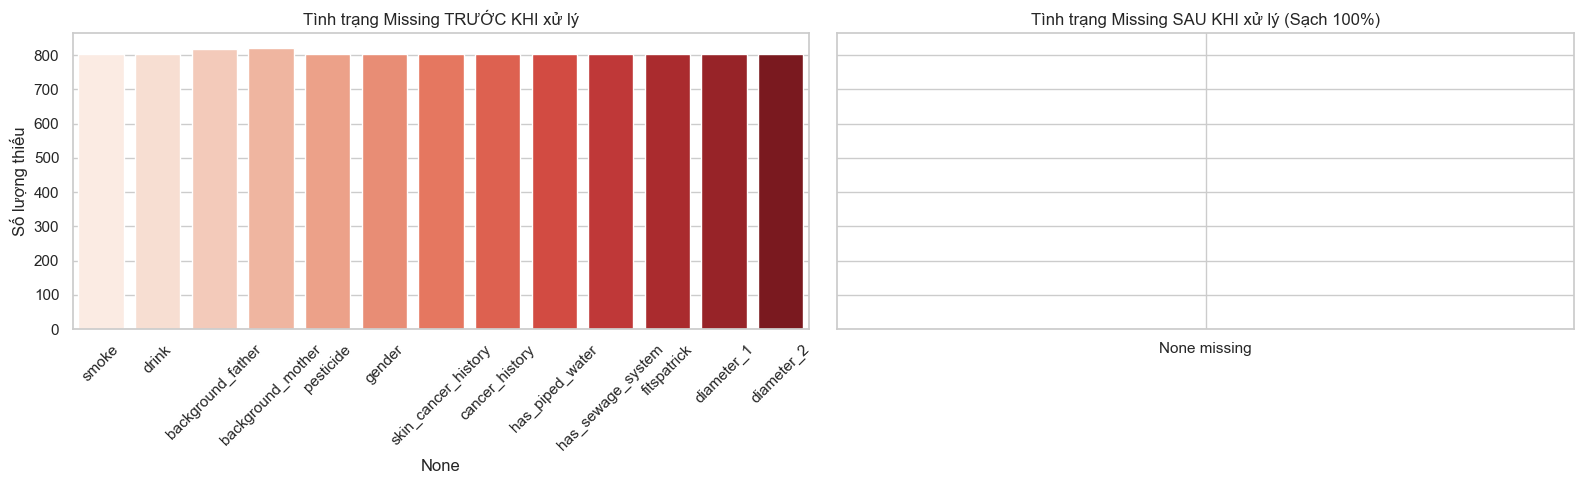

In [3]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = [c for c in df.select_dtypes(include=['object']).columns.tolist() if c not in id_cols] 
if 'diagnostic' in cat_cols: cat_cols.remove('diagnostic')

missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

if not missing_before.empty:
    sns.barplot(x=missing_before.index, y=missing_before.values, ax=axes[0], palette='Reds')
    axes[0].set_title('Tình trạng Missing TRƯỚC KHI xử lý')
    axes[0].set_ylabel('Số lượng thiếu')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].set_title('Tình trạng Missing TRƯỚC KHI xử lý (Không có)')

knn_imputer = KNNImputer(n_neighbors=5, weights="distance")
df[num_cols] = knn_imputer.fit_transform(df[num_cols])

for col in cat_cols:
    if df[col].isnull().sum() / len(df) > 0.15:
        df[col].fillna('Unknown', inplace=True)
    else:
        mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
        df[col].fillna(mode_val, inplace=True)

missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0]

if not missing_after.empty:
    sns.barplot(x=missing_after.index, y=missing_after.values, ax=axes[1], palette='Greens')
else:
    axes[1].bar(['None missing'], [0])
    axes[1].set_title('Tình trạng Missing SAU KHI xử lý (Sạch 100%)')

plt.tight_layout()
plt.show()

## 3. Khai thác Đặc trưng số & Biểu đồ phân phối

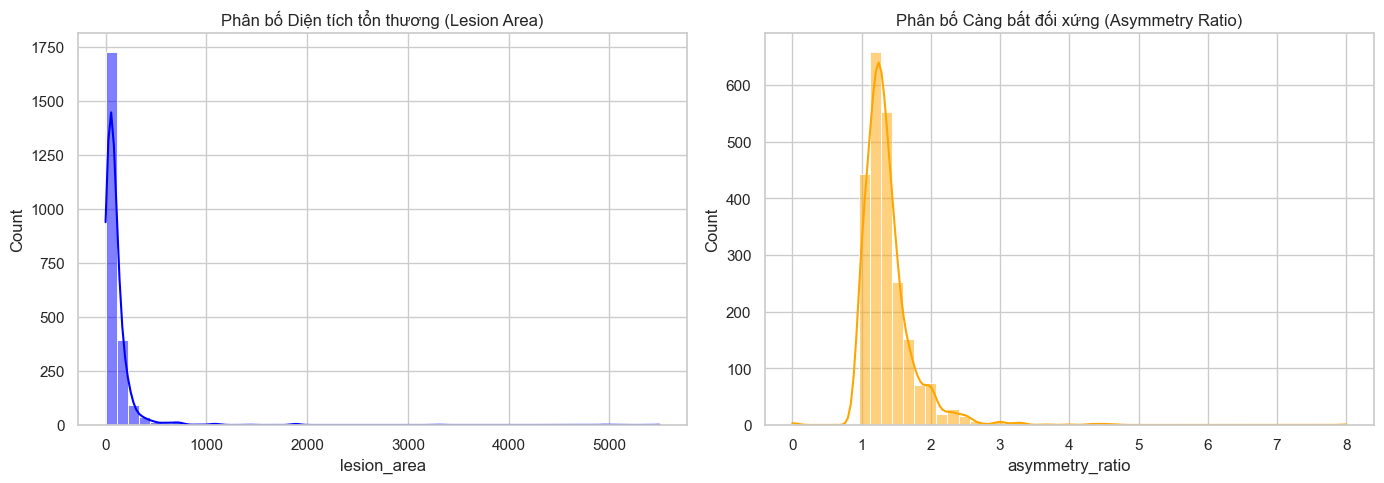

In [4]:
if 'diameter_1' in df.columns and 'diameter_2' in df.columns:
    df['lesion_area'] = math.pi * (df['diameter_1'] / 2) * (df['diameter_2'] / 2)
    df['asymmetry_ratio'] = df[['diameter_1', 'diameter_2']].max(axis=1) / (df[['diameter_1', 'diameter_2']].min(axis=1) + 1e-5)
    num_cols.extend(['lesion_area', 'asymmetry_ratio'])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(df['lesion_area'], bins=50, kde=True, ax=axes[0], color='blue')
    axes[0].set_title('Phân bố Diện tích tổn thương (Lesion Area)')
    
    sns.histplot(df['asymmetry_ratio'], bins=50, kde=True, ax=axes[1], color='orange')
    axes[1].set_title('Phân bố Càng bất đối xứng (Asymmetry Ratio)')
    plt.tight_layout()
    plt.show()

## 4. Mã Hoá & Chia dữ liệu (GroupShuffleSplit)

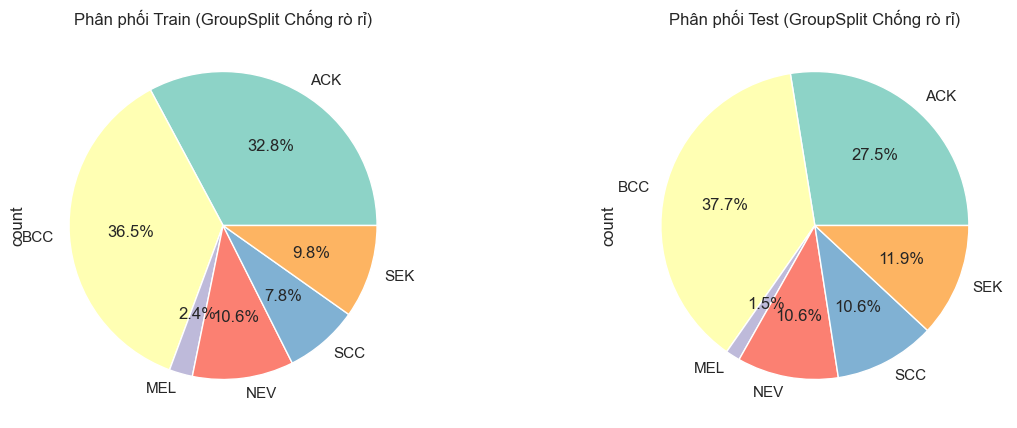

In [5]:
df_encoded = df.copy()
ordinal_features = ['fitzpatrick']
nominal_features = ['region', 'background_father', 'background_mother']
binary_features = [col for col in cat_cols if col not in ordinal_features + nominal_features]

target_col = 'diagnostic'
target_le = LabelEncoder()
y = target_le.fit_transform(df_encoded[target_col])

for col in ordinal_features + binary_features:
    if col in df_encoded:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        
df_encoded = pd.get_dummies(df_encoded, columns=[c for c in nominal_features if c in df_encoded], drop_first=True)
X = df_encoded.drop(columns=[target_col]) 

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=X['patient_id']))

X_train_full = X.iloc[train_idx].reset_index(drop=True)
X_test_full = X.iloc[test_idx].reset_index(drop=True)
y_train = y[train_idx]
y_test = y[test_idx]

train_mapping = X_train_full[id_cols].copy()
test_mapping = X_test_full[id_cols].copy()
train_mapping['target'] = y_train
test_mapping['target'] = y_test

test_mapping['is_synthetic'] = 0
os.makedirs('data_no_smote', exist_ok=True)
test_mapping.to_csv('data_no_smote/test_img_mapping.csv', index=False)

X_train = X_train_full.drop(columns=[c for c in id_cols if c in X_train_full.columns])
X_test = X_test_full.drop(columns=[c for c in id_cols if c in X_test_full.columns])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.Series(y_train).value_counts().sort_index().plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=sns.color_palette('Set3'), labels=target_le.classes_)
axes[0].set_title('Phân phối Train (GroupSplit Chống rò rỉ)')
pd.Series(y_test).value_counts().sort_index().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set3'), labels=target_le.classes_)
axes[1].set_title('Phân phối Test (GroupSplit Chống rò rỉ)')
plt.show()

train_mapping['is_synthetic'] = 0



## 5. SMOTETomek Đa phương thức (Ánh xạ Ảo ảnh)

In [6]:
X_train_res = X_train
y_train_res = y_train
train_mapping.to_csv('data_no_smote/train_img_mapping.csv', index=False)
print('Đã bỏ qua quy trình SMOTE và lưu file nguyên bản xuống data_no_smote/train_img_mapping.csv')


Đã bỏ qua quy trình SMOTE và lưu file nguyên bản xuống data_no_smote/train_img_mapping.csv


## 6. Khảo sát Tương quan (Heatmap)

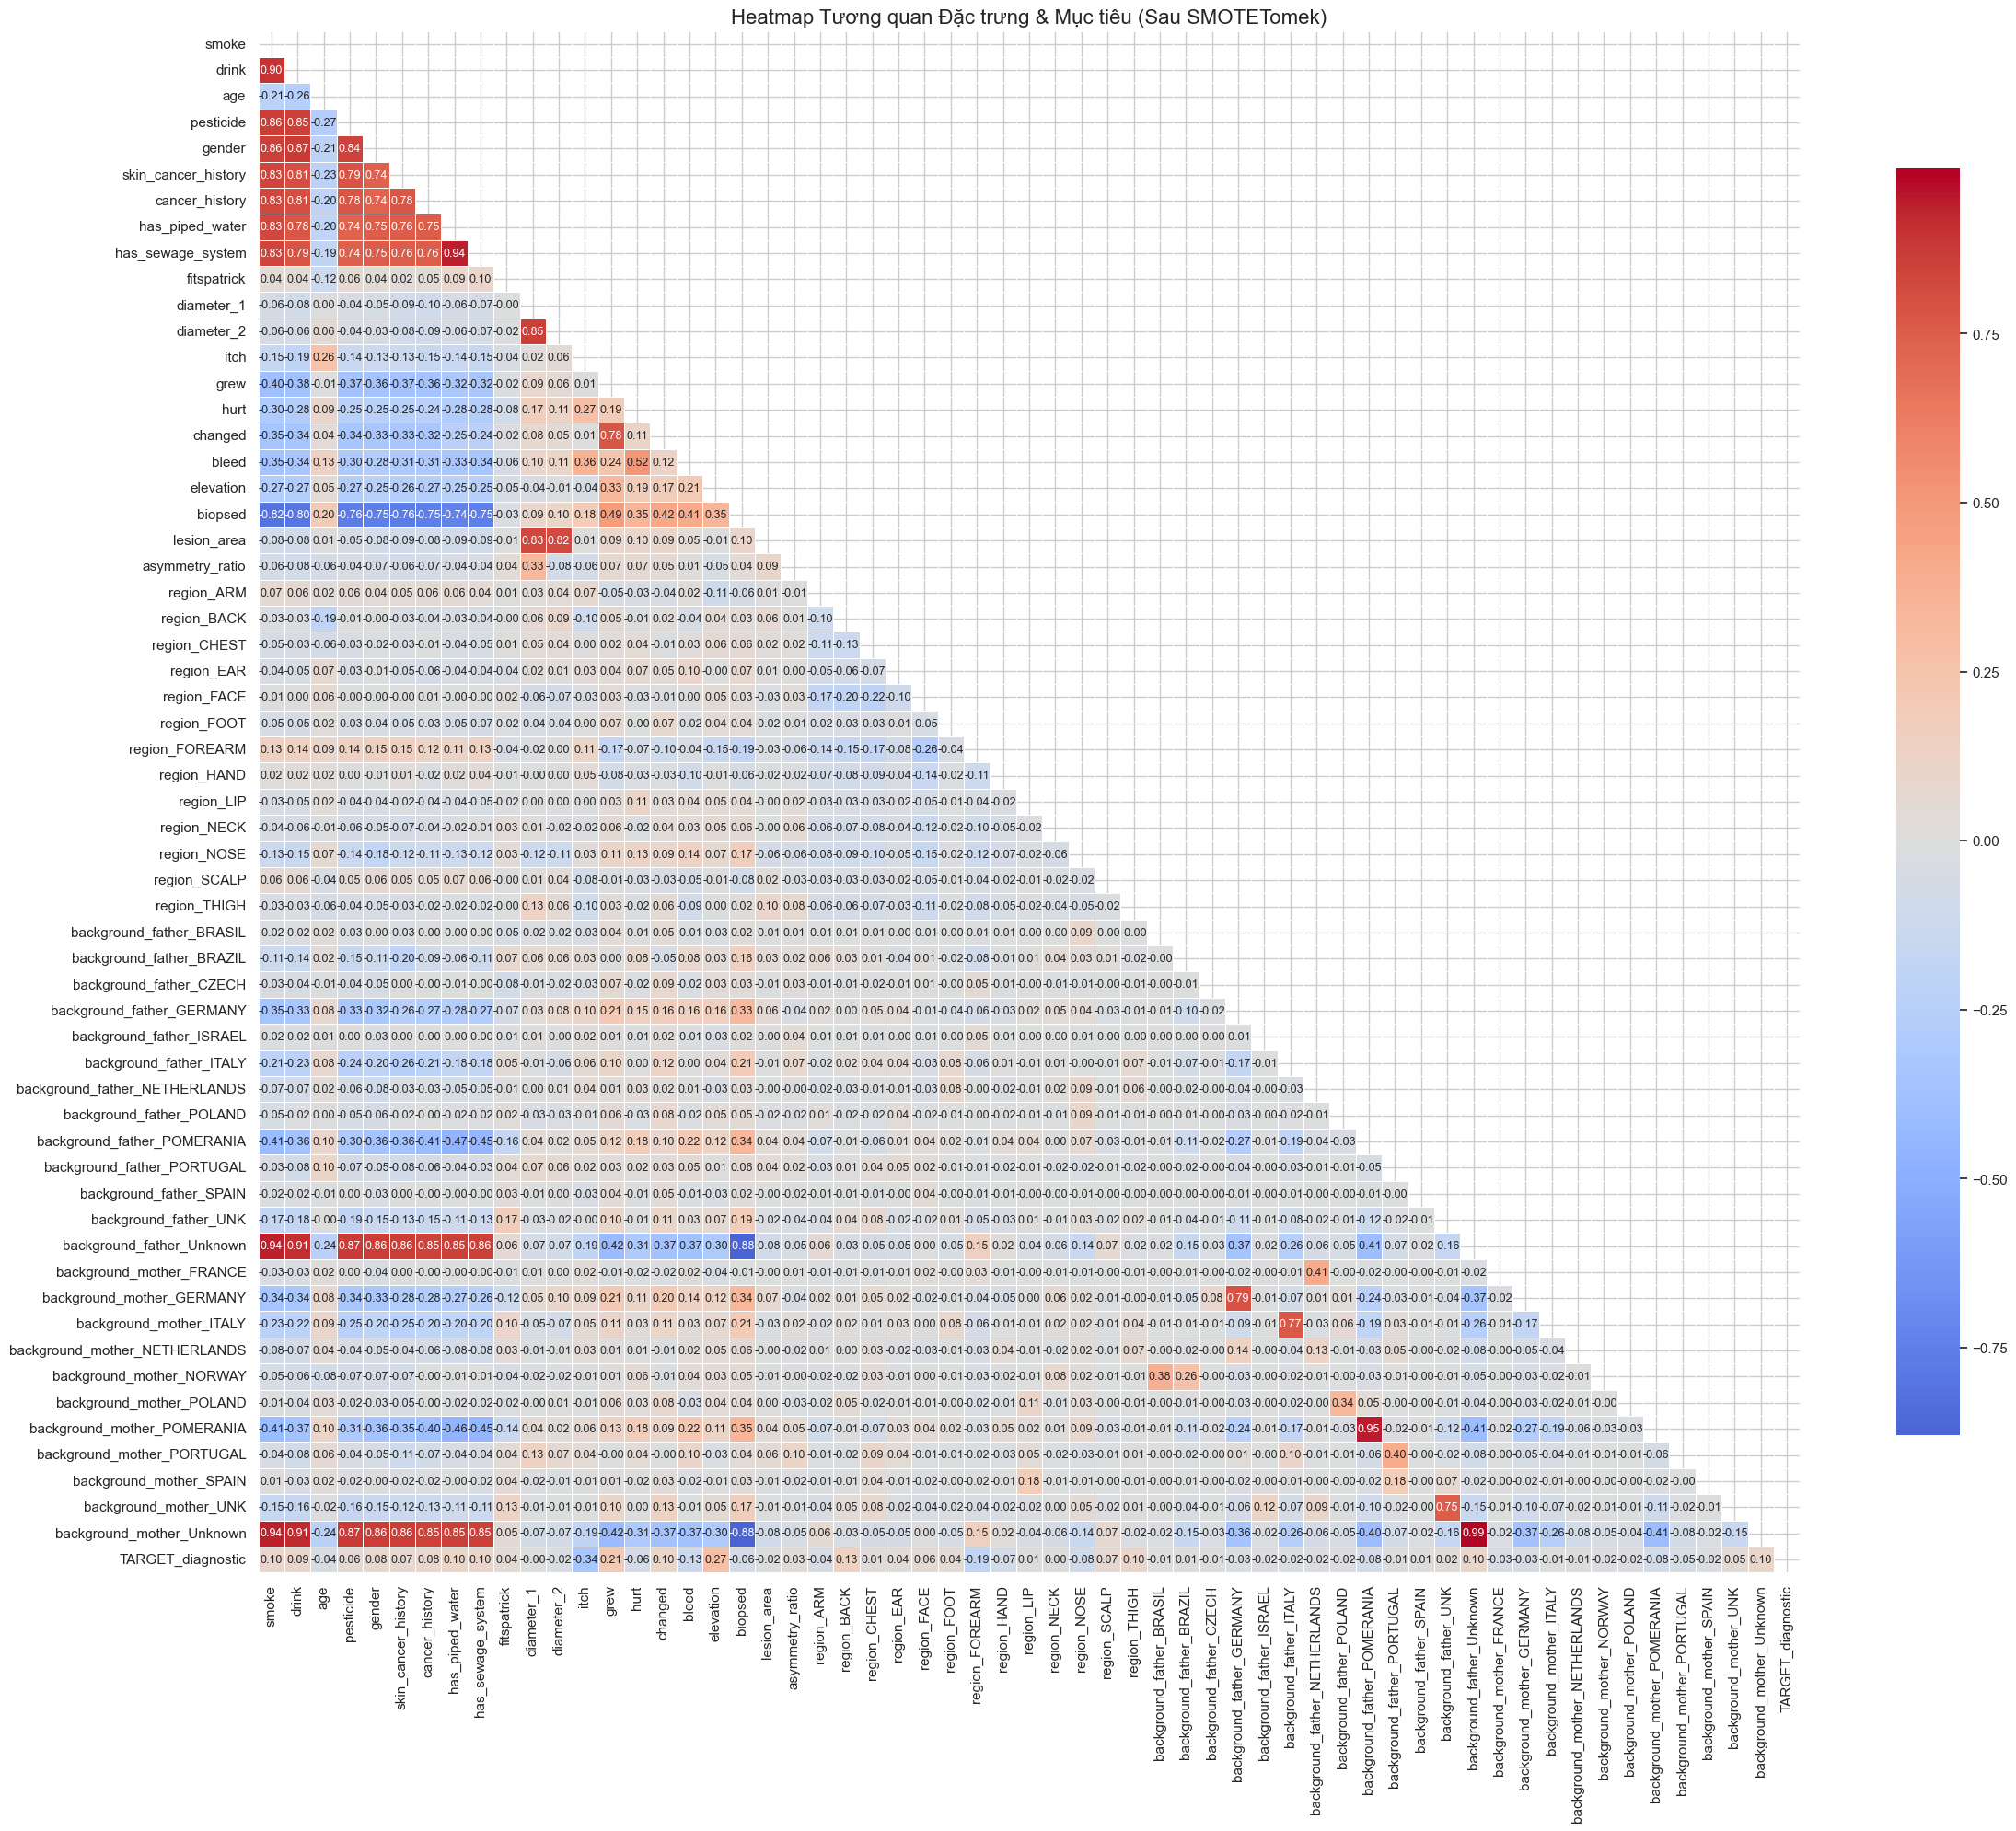

In [7]:
df_corr = X_train_res.copy()
df_corr['TARGET_diagnostic'] = y_train_res

plt.figure(figsize=(24, 20))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', annot_kws={'size': 9}, 
            cmap='coolwarm', center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Heatmap Tương quan Đặc trưng & Mục tiêu (Sau SMOTETomek)', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Lựa chọn Đặc trưng & Xuất File

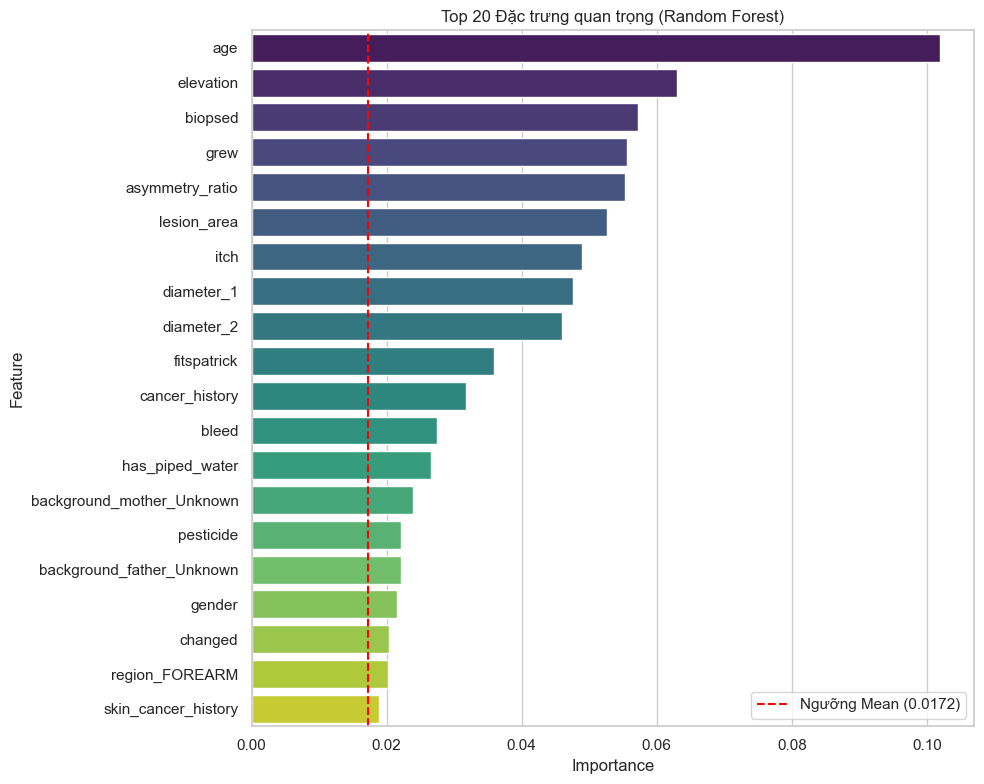

In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

importances = rf.feature_importances_
threshold = importances.mean()

feat_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_importances.head(20), palette='viridis')
plt.axvline(x=threshold, color='red', linestyle='--', label=f'Ngưỡng Mean ({threshold:.4f})')
plt.title('Top 20 Đặc trưng quan trọng (Random Forest)')
plt.legend()
plt.tight_layout()
plt.show()

selector = SelectFromModel(rf, threshold='mean', prefit=True)
X_train_final = selector.transform(X_train_res)
X_test_final = selector.transform(X_test)
selected_features = X_train.columns[selector.get_support()]

df_X_train_smote = pd.DataFrame(X_train_res, columns=X_train.columns)
df_X_test_smote = pd.DataFrame(X_test, columns=X_train.columns)
df_y_train_smote = pd.DataFrame(y_train_res, columns=[target_col])
df_y_test = pd.DataFrame(y_test, columns=[target_col])
df_X_train_smote.to_csv('data_no_smote/X_train_before_selection.csv', index=False)
df_X_test_smote.to_csv('data_no_smote/X_test_before_selection.csv', index=False)
df_y_train_smote.to_csv('data_no_smote/y_train.csv', index=False)
df_y_test.to_csv('data_no_smote/y_test.csv', index=False)

df_X_train_final = pd.DataFrame(X_train_final, columns=selected_features)
df_X_test_final = pd.DataFrame(X_test_final, columns=selected_features)
df_X_train_final.to_csv('data_no_smote/X_train_after_selection.csv', index=False)
df_X_test_final.to_csv('data_no_smote/X_test_after_selection.csv', index=False)
